In [31]:
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

DATA_DIR = 'data'

def get_sit_to_stand_files(data_dir=DATA_DIR):
    """
    Returns: list
        Two lists of file paths, one for yes and one for no
    """

    # Create the pattern to match files like {name}_1_{yes/no}.csv
    pattern = os.path.join(data_dir, '*_1_*.csv')
    
    # Get all matching files
    files = glob.glob(pattern)
    
    # Filter to ensure we only get yes/no files
    files = [f for f in files if f.endswith('_yes.csv') or f.endswith('_no.csv')]

    # Sort the files to ensure consistent ordering
    files.sort()

    # Return two lists of files, one for yes and one for no
    return [f for f in files if f.endswith('_yes.csv')], [f for f in files if f.endswith('_no.csv')]

def get_water_task_files(data_dir=DATA_DIR):
    """
    Returns: list
        Two lists of file paths, one for yes and one for no
    """

    # Create the pattern to match files like {name}_1_{yes/no}.csv
    pattern = os.path.join(data_dir, '*_2_*.csv')

    # Get all matching files
    files = glob.glob(pattern)
    
    # Filter to ensure we only get yes/no files
    files = [f for f in files if f.endswith('_yes.csv') or f.endswith('_no.csv')]

    # Sort the files to ensure consistent ordering
    files.sort()

    # Return two lists of files, one for yes and one for no
    return [f for f in files if f.endswith('_yes.csv')], [f for f in files if f.endswith('_no.csv')]

def get_step_count_task_files(data_dir=DATA_DIR):
    """
    Returns: list
        Two lists of file paths, one for yes and one for no
    """

    # Create the pattern to match files like {name}_1_{yes/no}.csv
    pattern = os.path.join(data_dir, '*_3_*.csv')

    # Get all matching files
    files = glob.glob(pattern)
    
    # Filter to ensure we only get yes/no files
    files = [f for f in files if f.endswith('_yes.csv') or f.endswith('_no.csv')]

    # Sort the files to ensure consistent ordering
    files.sort()

    # Return two lists of files, one for yes and one for no
    return [f for f in files if f.endswith('_yes.csv')], [f for f in files if f.endswith('_no.csv')]
    


In [32]:
get_water_task_files()

(['data/ashish_2_yes.csv',
  'data/enas_2_yes.csv',
  'data/ghefar_2_yes.csv',
  'data/nour_2_yes.csv',
  'data/p10_2_yes.csv',
  'data/p4_2_yes.csv',
  'data/p5_2_yes.csv',
  'data/p8_2_yes.csv',
  'data/p9_2_yes.csv',
  'data/xhoel_2_yes.csv'],
 ['data/ashish_2_no.csv',
  'data/enas_2_no.csv',
  'data/ghefar_2_no.csv',
  'data/nour_2_no.csv',
  'data/p10_2_no.csv',
  'data/p4_2_no.csv',
  'data/p5_2_no.csv',
  'data/p8_2_no.csv',
  'data/p9_2_no.csv',
  'data/xhoel_2_no.csv'])

In [33]:
# Construct dataframes for each task

import pandas as pd

water_task_yes, water_task_no = get_water_task_files()

dfs_water_task_yes = [pd.read_csv(f) for f in water_task_yes]
dfs_water_task_no = [pd.read_csv(f) for f in water_task_no]


In [34]:
def preprocess_sit_to_stand_data(df):
    """
    Preprocess the sit to stand data.
    """
    from scipy import signal, integrate
    import numpy as np

    # Convert timestamp_ms to seconds starting from 0
    df['time_s'] = (df['timestamp_ms'] - df['timestamp_ms'].min()) / 1000

    # Calculate magnitude of acceleration 
    df['acceleration_magnitude'] = np.sqrt(
        df['freeAcceleration_m/s²_x']**2 + 
        df['freeAcceleration_m/s²_y']**2 + 
        df['freeAcceleration_m/s²_z']**2
    )

    # Apply detrending to each axis
    df['acc_detrended_x'] = signal.detrend(df['freeAcceleration_m/s²_x'], type='linear')
    df['acc_detrended_y'] = signal.detrend(df['freeAcceleration_m/s²_y'], type='linear')
    df['acc_detrended_z'] = signal.detrend(df['freeAcceleration_m/s²_z'], type='linear')

    # Calculate detrended magnitude of acceleration
    df['acceleration_magnitude_detrended'] = np.sqrt(df['acc_detrended_x']**2 + df['acc_detrended_y']**2 + df['acc_detrended_z']**2)

    # Calculate velocity with detrending
    df['velocity_z'] = integrate.cumulative_trapezoid(df['acc_detrended_z'], df['time_s'], initial=0)
    df['velocity_x'] = integrate.cumulative_trapezoid(df['acc_detrended_x'], df['time_s'], initial=0)
    df['velocity_y'] = integrate.cumulative_trapezoid(df['acc_detrended_y'], df['time_s'], initial=0)

    # Calculate magnitude of velocity
    df['velocity_magnitude'] = np.sqrt(df['velocity_x']**2 + df['velocity_y']**2 + df['velocity_z']**2)

    # Calculate position with detrending
    df['position_z'] = integrate.cumulative_trapezoid(df['velocity_z'], df['time_s'], initial=0)
    df['position_x'] = integrate.cumulative_trapezoid(df['velocity_x'], df['time_s'], initial=0)
    df['position_y'] = integrate.cumulative_trapezoid(df['velocity_y'], df['time_s'], initial=0)

    return df

dfs_cognitive = [preprocess_sit_to_stand_data(df) for df in dfs_water_task_yes]
dfs_standard = [preprocess_sit_to_stand_data(df) for df in dfs_water_task_no]

# Exploration

In [35]:
def plot_column_sns(df, column_names=[], title=None):
    sns.set_style('whitegrid')

    color_palatte = 'colorblind'
    sns.set_palette(color_palatte)
    plt.figure(figsize=(18, 6))
    for i, column_name in enumerate(column_names):
        # plot the column_name vs time_s and include appropriate legend
        sns.lineplot(
            data=df,
            x='time_s',
            y=column_name,
            alpha=0.8,
            label=column_name
        ) 
        plt.xticks(np.arange(0.0, 25.5, 1)) 
        plt.yticks(np.arange(-10, 15, 1))
        plt.tight_layout()
    plt.title(title)
    plt.show()

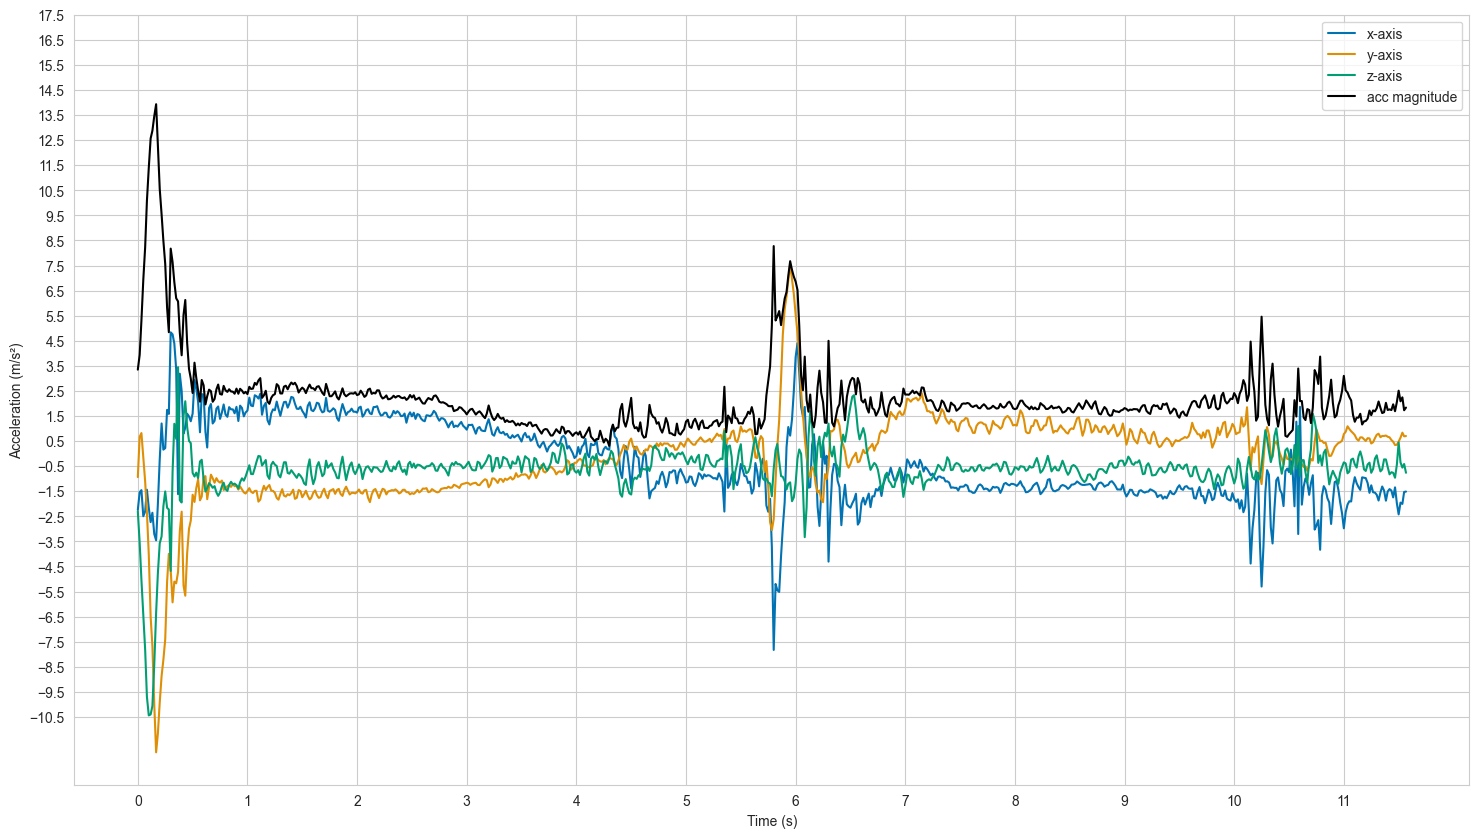

In [36]:
# Plot a single participant's data
df = dfs_cognitive[0]

sns.set_style('whitegrid')
sns.set_palette('colorblind')

# plot acceleration along x, y and z axis
plt.figure(figsize=(18, 10))
sns.lineplot(data=df, x='time_s', y='freeAcceleration_m/s²_x', label='x-axis')
sns.lineplot(data=df, x='time_s', y='freeAcceleration_m/s²_y', label='y-axis')
sns.lineplot(data=df, x='time_s', y='freeAcceleration_m/s²_z', label='z-axis')
sns.lineplot(data=df, x='time_s', y='acceleration_magnitude', label='acc magnitude', color='black')

plt.xticks(np.arange(0.0, 11.5, 1))
plt.yticks(np.arange(-10.5, 18, 1))

# # draw a horizontal line at y=0
# plt.axhline(y=0, color='black', linewidth=1)


plt.xlabel('Time (s)')
plt.ylabel('Acceleration (m/s²)')

# plt.title('Acceleration along x, y and z axis for Standard Sit to Stand task')
# plt.tight_layout()
plt.legend()


In [37]:
# for i, dframe in enumerate(dfs_standard):
#     plot_column_sns(dframe, ['freeAcceleration_m/s²_x', 'freeAcceleration_m/s²_y', 'freeAcceleration_m/s²_z'], title='Standard Participant ' + str(i+1))
#     plot_column_sns(dfs_cognitive[i], ['freeAcceleration_m/s²_x', 'freeAcceleration_m/s²_y', 'freeAcceleration_m/s²_z'], title='Cognitive Participant ' + str(i+1))
#     plt.show()
    

In [38]:
# Function to plot two dataframes in a single plot

def plot_two_dataframes(df_standard, df_cognitive, column_names=[], title=None):
    sns.set_style('whitegrid')
    sns.set_palette('colorblind')

    plt.figure(figsize=(18, 6))
    for i, column_name in enumerate(column_names):
        sns.lineplot(data=df_standard, x='time_s', y=column_name, label='Standard')
        sns.lineplot(data=df_cognitive, x='time_s', y=column_name, label='Cognitive')
    plt.legend()
    plt.title(title)
    plt.show()

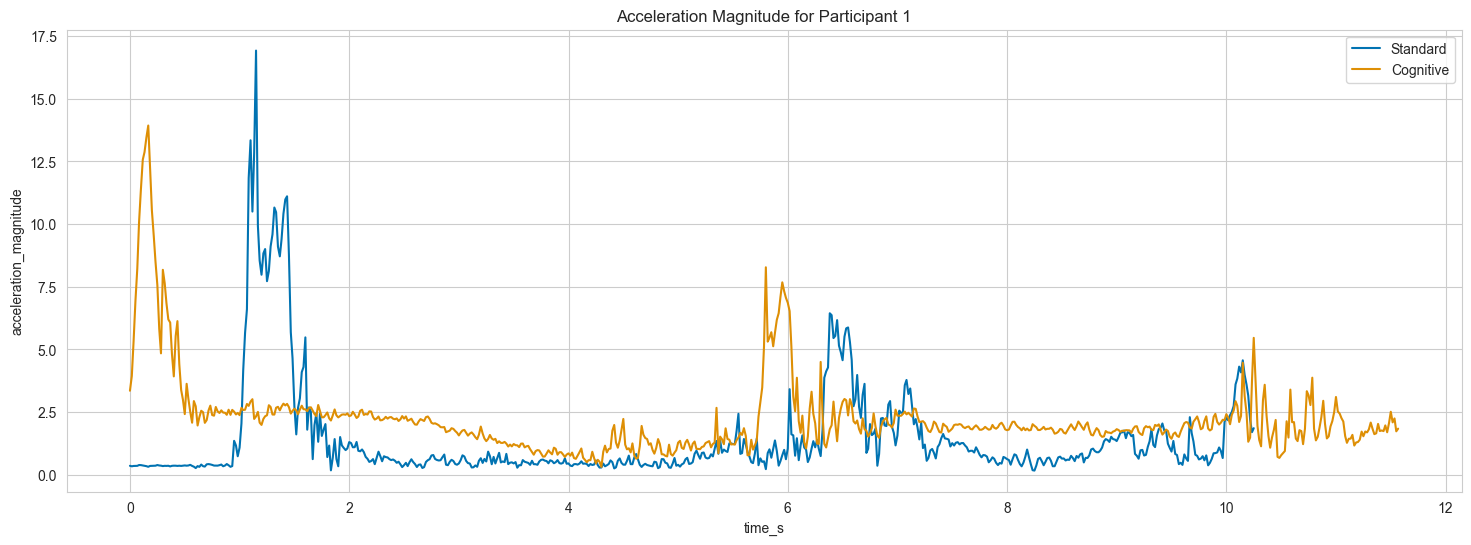

In [39]:
for i in range(len(dfs_standard)):
    plot_two_dataframes(dfs_standard[i], dfs_cognitive[i], ['acceleration_magnitude'], title=f'Acceleration Magnitude for Participant {i+1}')
    break

In [40]:
# Calculate times
print('Standard')
print('--------------------------------')
for i, dframe in enumerate(dfs_standard):
    print(f"Number of seconds in {i}th participant is {dframe['time_s'].iloc[-1]}")
print('\n\n')


print('Challenge')
print('--------------------------------')
for i, dframe in enumerate(dfs_cognitive):
    print(f"Number of seconds in {i}th participant is {dframe['time_s'].iloc[-1]}")

Standard
--------------------------------
Number of seconds in 0th participant is 10.25
Number of seconds in 1th participant is 21.567
Number of seconds in 2th participant is 22.034
Number of seconds in 3th participant is 14.267
Number of seconds in 4th participant is 9.2
Number of seconds in 5th participant is 10.567
Number of seconds in 6th participant is 10.45
Number of seconds in 7th participant is 9.884
Number of seconds in 8th participant is 8.617
Number of seconds in 9th participant is 9.517



Challenge
--------------------------------
Number of seconds in 0th participant is 11.567
Number of seconds in 1th participant is 22.517
Number of seconds in 2th participant is 29.951
Number of seconds in 3th participant is 14.9
Number of seconds in 4th participant is 10.25
Number of seconds in 5th participant is 13.367
Number of seconds in 6th participant is 13.6
Number of seconds in 7th participant is 11.467
Number of seconds in 8th participant is 10.75
Number of seconds in 9th particip

In [41]:
# Make lists of time taken for each participant to complete the challenge
time_taken_standard = []
for i, dframe in enumerate(dfs_standard):
    time_taken_standard.append(dframe['time_s'].iloc[-1])

time_taken_challenge = []
for i, dframe in enumerate(dfs_cognitive):
    time_taken_challenge.append(dframe['time_s'].iloc[-1])

print(time_taken_standard)
print(time_taken_challenge)

print(f"Mean time taken for standard is {np.mean(time_taken_standard)}")
print(f"Mean time taken for challenge is {np.mean(time_taken_challenge)}")


[np.float64(10.25), np.float64(21.567), np.float64(22.034), np.float64(14.267), np.float64(9.2), np.float64(10.567), np.float64(10.45), np.float64(9.884), np.float64(8.617), np.float64(9.517)]
[np.float64(11.567), np.float64(22.517), np.float64(29.951), np.float64(14.9), np.float64(10.25), np.float64(13.367), np.float64(13.6), np.float64(11.467), np.float64(10.75), np.float64(13.067)]
Mean time taken for standard is 12.635299999999999
Mean time taken for challenge is 15.143600000000001


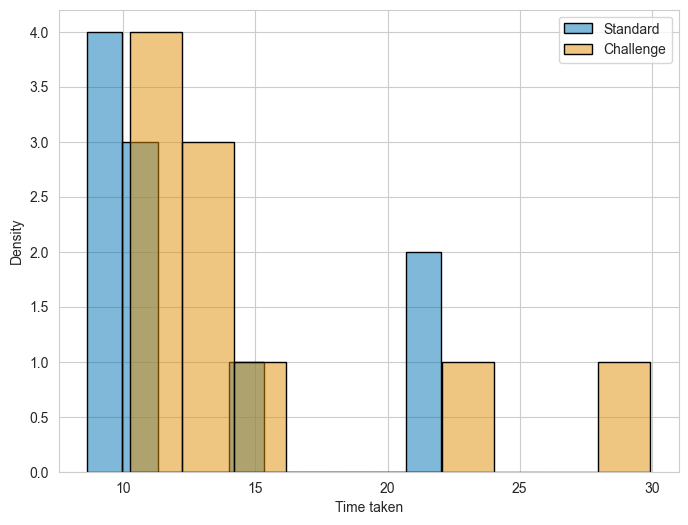

In [42]:
# Plot the time_taken_standard and time_taken_challenge

plt.figure(figsize=(8, 6))
sns.histplot(time_taken_standard, bins=10, alpha=0.5, label='Standard', edgecolor='black')
sns.histplot(time_taken_challenge, bins=10, alpha=0.5, label='Challenge', edgecolor='black')
plt.xlabel('Time taken')
plt.ylabel('Density')
plt.legend()
plt.show()

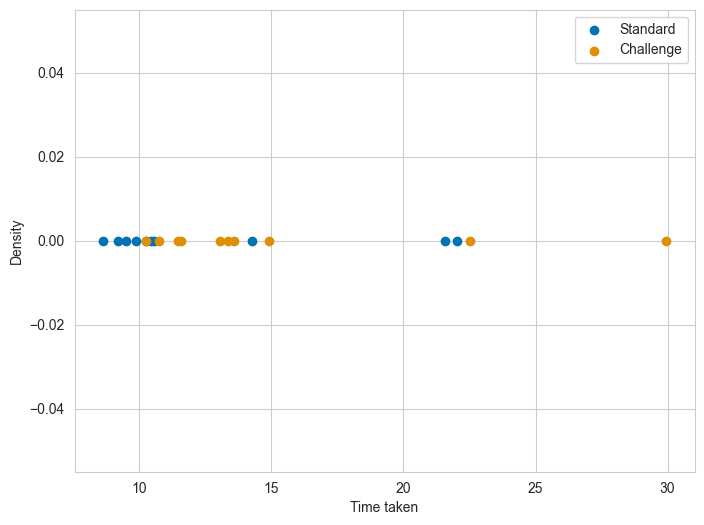

In [43]:
# Plot the points of time taken for standard and challenge

plt.figure(figsize=(8, 6))
plt.scatter(time_taken_standard, np.zeros_like(time_taken_standard), label='Standard')
plt.scatter(time_taken_challenge, np.zeros_like(time_taken_challenge), label='Challenge')
plt.xlabel('Time taken')
plt.ylabel('Density')
plt.legend()
plt.show()

In [44]:
# Check for normality of time taken for standard and challenge
from scipy import stats
print(stats.shapiro(time_taken_standard))
print(stats.shapiro(time_taken_challenge))

# Plot the time taken for standard and challenge
# plt.figure(figsize=(16, 5))
# plt.hist(time_taken_standard, bins=20, alpha=0.5, label='Standard')
# plt.hist(time_taken_challenge, bins=20, alpha=0.5, label='Challenge')
# plt.xlabel('Time Taken (s)')
# plt.ylabel('Frequency')

# # Add a fit line for the standard and challenge
# plt.legend()
# plt.show()

# Conclusion
if stats.shapiro(time_taken_standard)[1] > 0.05:
    print("Time taken for standard is normally distributed")
else:
    print("Time taken for standard is not normally distributed")

if stats.shapiro(time_taken_challenge)[1] > 0.05:
    print("Time taken for challenge is normally distributed")


ShapiroResult(statistic=np.float64(0.7184586864640637), pvalue=np.float64(0.001475227323043977))
ShapiroResult(statistic=np.float64(0.740616906131071), pvalue=np.float64(0.0027433013586801273))
Time taken for standard is not normally distributed


In [45]:
time_taken_standard = np.array(time_taken_standard)
time_taken_challenge = np.array(time_taken_challenge)

In [46]:
time_taken_standard, time_taken_challenge

(array([10.25 , 21.567, 22.034, 14.267,  9.2  , 10.567, 10.45 ,  9.884,
         8.617,  9.517]),
 array([11.567, 22.517, 29.951, 14.9  , 10.25 , 13.367, 13.6  , 11.467,
        10.75 , 13.067]))

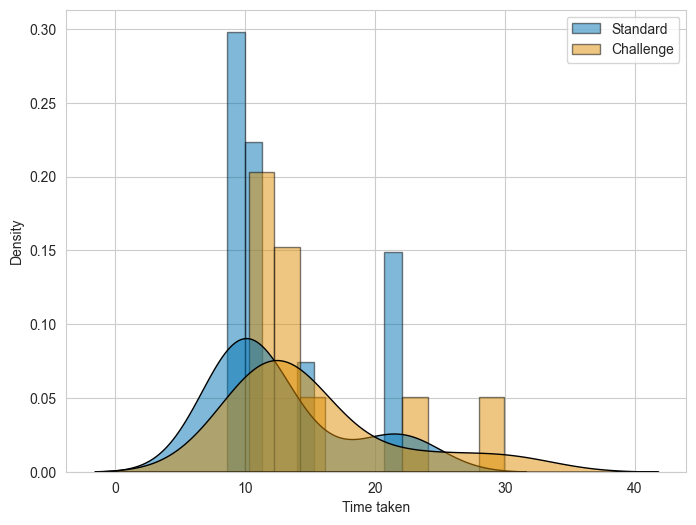

In [47]:
plt.figure(figsize=(8, 6))
plt.hist(time_taken_standard, bins=10, alpha=0.5, label='Standard', edgecolor='black', density=True)
plt.hist(time_taken_challenge, bins=10, alpha=0.5, label='Challenge', edgecolor='black', density=True)
# Plot a fit line
cb_colors = sns.color_palette("colorblind", as_cmap=True)
sns.kdeplot(time_taken_standard, fill=True, alpha=0.5, edgecolor='black', color=cb_colors[0],)
sns.kdeplot(time_taken_challenge, fill=True, alpha=0.5, edgecolor='black', color=cb_colors[1])
# plt.title('Distribution of Time Taken for Standard and Challenge Sit to Stand tasks')
plt.xlabel('Time taken')
plt.ylabel('Density')
plt.legend()
plt.show()

Shapiro-Wilk test: p-value = 0.0090
Context: If p-value is less than 0.05, the data is not normally distributed. 
Result:
The data is not normally distributed


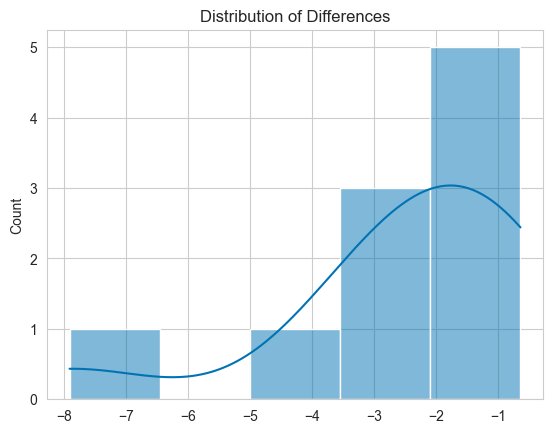

In [48]:
from scipy.stats import shapiro

diff = time_taken_standard - time_taken_challenge
stat, p = shapiro(diff)
print(f"Shapiro-Wilk test: p-value = {p:.4f}")

print("Context: If p-value is less than 0.05, the data is not normally distributed. \nResult:")

if p < 0.05:
    print("The data is not normally distributed")
else:
    print("The data is normally distributed")

import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(diff, kde=True)
plt.title("Distribution of Differences")
plt.show()


/var/folders/zp/3681gr8x5mg9vt0z3xbtlzx00000gn/T/ipykernel_39403/1782571995.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


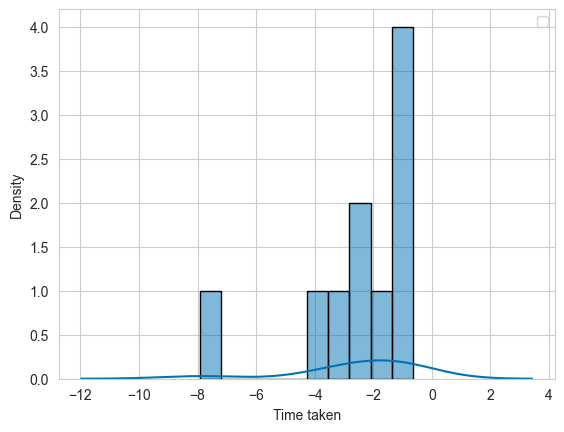

In [49]:
sns.histplot(diff, bins=10, alpha=0.5, edgecolor='black')
plt.xlabel('Time taken')
plt.ylabel('Density')
sns.kdeplot(diff,)
plt.legend()
plt.show()

In [50]:
from scipy.stats import ttest_rel

t_stat, p_val = ttest_rel(time_taken_standard, time_taken_challenge)
print(time_taken_challenge, time_taken_standard)
print(f"Paired t-test: t = {t_stat:.3f}, p = {p_val:.4f}")

if p_val <= 0.05:
    print("Reject H_0: significant difference between the paired groups. Hence, the mean of the two groups are significantly different.")
else:
    print("Fail to reject H_0: no significant difference")


[11.567 22.517 29.951 14.9   10.25  13.367 13.6   11.467 10.75  13.067] [10.25  21.567 22.034 14.267  9.2   10.567 10.45   9.884  8.617  9.517]
Paired t-test: t = -3.702, p = 0.0049
Reject H_0: significant difference between the paired groups. Hence, the mean of the two groups are significantly different.


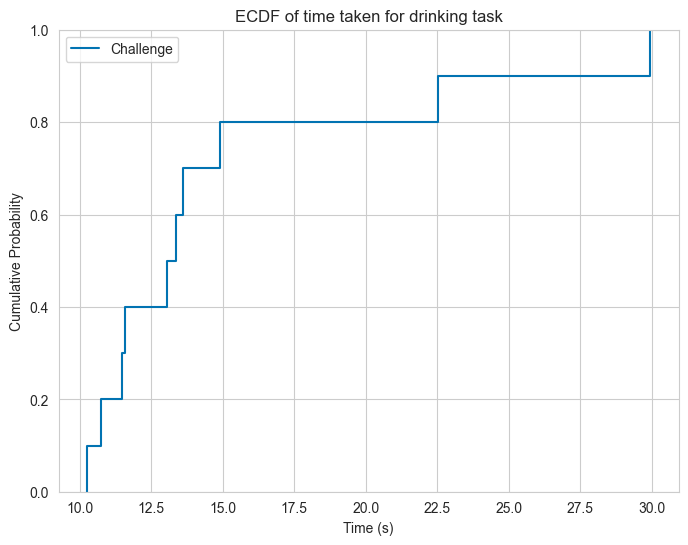

In [51]:
# Plot empirical cumulative distribution function (ECDF) for counts
plt.figure(figsize=(8, 6))
sns.ecdfplot(data=time_taken_challenge, label='Challenge')
plt.title('ECDF of time taken for drinking task')
plt.xlabel('Time (s)')
plt.ylabel('Cumulative Probability')
plt.legend()
plt.show()

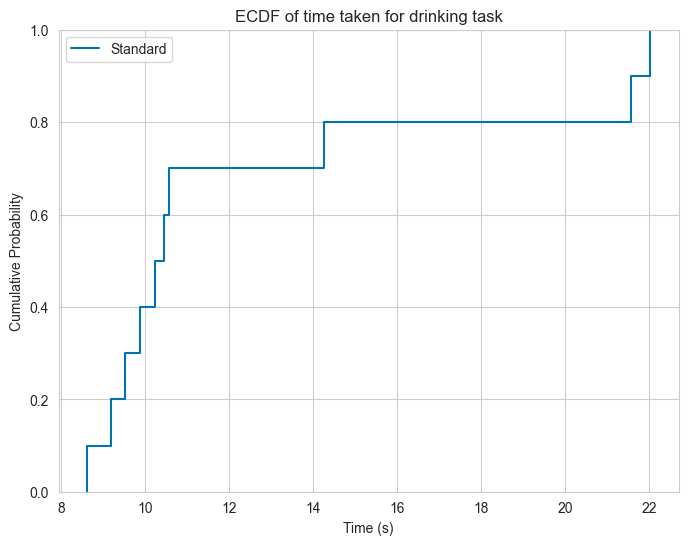

In [52]:

# Plot empirical cumulative distribution function (ECDF) for counts
plt.figure(figsize=(8, 6))
sns.ecdfplot(data=time_taken_standard, label='Standard')
plt.title('ECDF of time taken for drinking task')
plt.xlabel('Time (s)')
plt.ylabel('Cumulative Probability')
plt.legend()
plt.show()

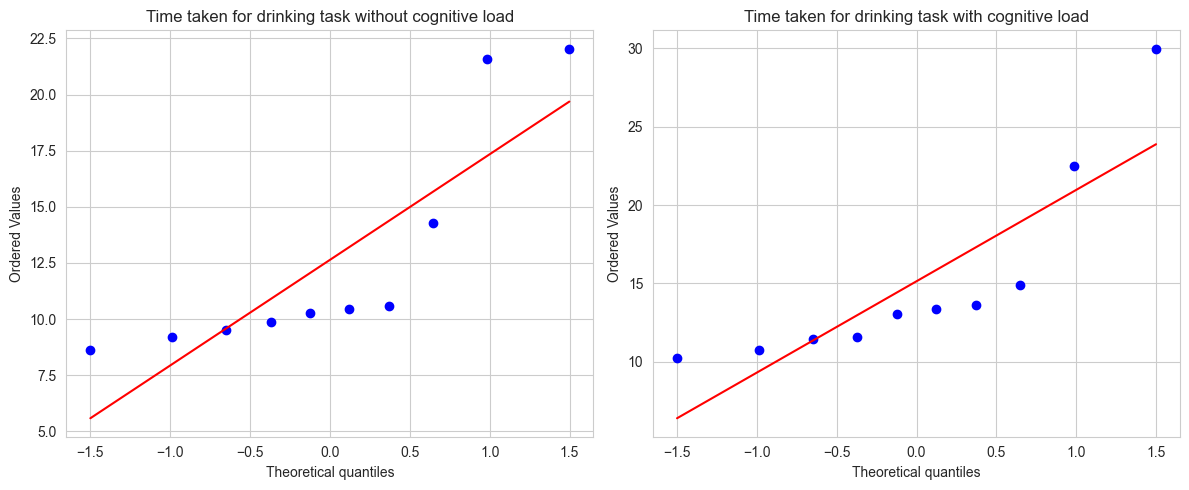

In [53]:
# Create Q-Q plots to assess normality
import scipy.stats as stats
import matplotlib.pyplot as plt

# Set up subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Q-Q plot for standard condition
stats.probplot(time_taken_standard, dist="norm", plot=ax1)
ax1.set_title("Time taken for drinking task without cognitive load")

# Q-Q plot for challenge condition  
stats.probplot(time_taken_challenge, dist="norm", plot=ax2, )
ax2.set_title("Time taken for drinking task with cognitive load")

plt.tight_layout()
plt.show()


In [54]:
# Applying Wilcoxon signed-rank test to check if the mean of counts_challenge is significantly different from the mean of counts_standard
from scipy.stats import wilcoxon

stat, p = wilcoxon(time_taken_standard, time_taken_challenge)
print(f"Wilcoxon signed-rank test: statistic = {stat:.3f}, p-value = {p:.4f}")

if p < 0.05:
    print("Reject H_0: significant difference between the paired groups. Hence, the mean of the two groups are significantly different.")
else:
    print("Fail to reject H_0: no significant difference")

Wilcoxon signed-rank test: statistic = 0.000, p-value = 0.0020
Reject H_0: significant difference between the paired groups. Hence, the mean of the two groups are significantly different.


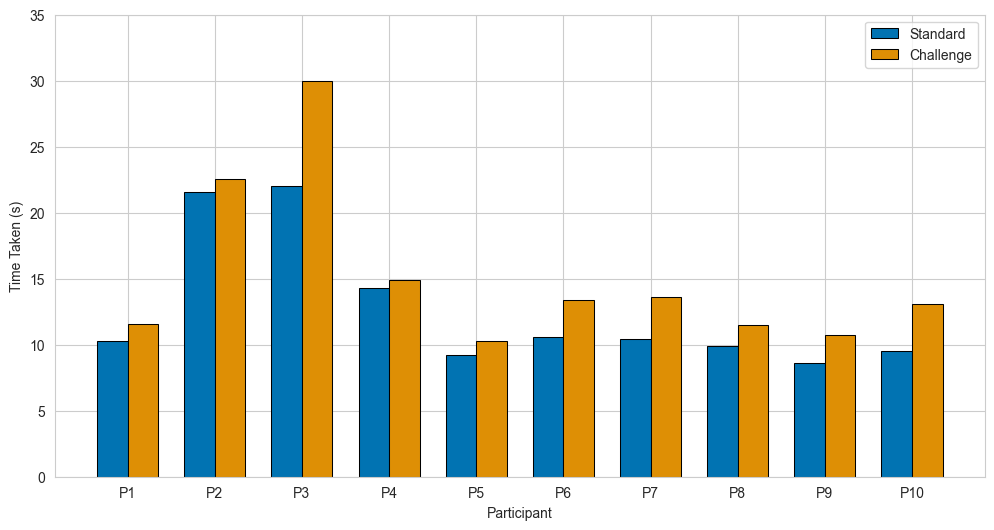

In [64]:
ind = np.arange(len(time_taken_standard))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(ind, time_taken_standard, width, label='Standard',  edgecolor='black', linewidth=0.75,)
plt.bar(ind + width, time_taken_challenge, width, label='Challenge',  edgecolor='black', linewidth=0.75,)
sns.set_palette('colorblind')
sns.set_style('whitegrid')
# Labels and title
plt.ylabel('Time Taken (s)')
plt.xlabel('Participant')
# plt.title('Comparison of Number of Standard vs Challenge Counts')
plt.xticks(ind + width / 2, [f'P{i+1}' for i in range(len(time_taken_standard))])
plt.legend()
plt.yticks(np.arange(0, 35.5, 5))
plt.show()